# Lab 11 — Convolution จากศูนย์ด้วย numpy
### Images as matrices, the convolution operator, padding, stride, volumes, pooling

**กลุ่ม:** E CNN · **อ่านคู่กับสไลด์หน้า:** 153-200 · **เวลาโดยประมาณ:** 120 นาที · **Dataset:** digits 8×8 (sklearn), MNIST 1 ภาพ 28×28, ภาพ RGB สังเคราะห์, ภาพ 6×6 กับ filter 3×3 จากสไลด์

**ควรทำมาก่อน:** Lab 01 (numpy: shape, `*` กับ `@`, slicing) — ส่วน torch ในขั้นที่ 6 ใช้แค่ `torch.tensor` กับฟังก์ชัน 2 ตัว

## จุดประสงค์การเรียนรู้
เมื่อทำ lab นี้จบ นิสิตจะสามารถ
1. อธิบายได้ว่าภาพคือ matrix `(n_H, n_W)` หรือ volume `(n_H, n_W, n_C)` และทำไมการ flatten แล้วต่อ fully-connected network จึงไม่เหมาะกับภาพ
2. เขียน convolution operator ด้วย loop สองชั้น และทำซ้ำตัวเลขในสไลด์ p.166-184 ได้ทุกช่อง
3. คำนวณขนาด output จากสูตร $\lfloor (n + 2p - f)/s \rfloor + 1$ และอธิบายบทบาทของ padding กับ stride
4. ทำ convolution ของ volume กับ filter หลายตัว และนับจำนวน parameter ของชั้น conv ได้
5. ทำ max pooling ด้วยมือ และเทียบผลทุกอย่างกับ `torch.nn.functional` (conv2d, max_pool2d) พร้อมแปลง layout `(H, W, C)` ↔ `(N, C, H, W)`

> **วิธีใช้ notebook นี้:** อ่าน markdown cell ก่อน แล้วรัน code cell ถัดไปด้วย `Shift+Enter` ทีละ cell ตามลำดับ
> ทุก code cell มีคำอธิบายว่าทำอะไรและทำไม ถ้าอยากทดลอง ให้แก้ตัวเลขใน cell แล้วรันซ้ำได้เลย

## เตรียมเครื่องมือ
cell แรกของทุก lab จะ import library ที่ใช้ และตั้ง **seed** ให้ตัวเลขสุ่มเหมือนกันทุกครั้งที่รัน
(ไม่งั้นค่าเริ่มต้นของ weight จะต่างกันทุกรอบ และตัวเลขในหน้าจอจะไม่ตรงกับคำอธิบาย)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import nnlab                      # package ประกอบ lab (ติดตั้งแล้วด้วย uv sync)
except ImportError:                   # เผื่อเปิดด้วย kernel อื่น: เพิ่ม lab/src เข้า path เอง
    import sys, pathlib
    sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
    import nnlab

from nnlab.utils import set_seed
import torch
import torch.nn.functional as F
rng = set_seed(463)                   # 463 = เลขวิชา CP463
np.set_printoptions(precision=4, suppress=True)
%matplotlib inline
print("numpy", np.__version__, "| nnlab", nnlab.__version__)

numpy 2.2.6 | nnlab 0.1.0


## สัญลักษณ์ในบทนี้
| สัญลักษณ์ | ความหมาย | ที่มา |
|---|---|---|
| $n_H \times n_W \times n_C$ | ความสูง × ความกว้าง × จำนวน channel ของภาพ (grayscale $n_C = 1$, RGB $n_C = 3$) | p.161-162 |
| $I * F$ | convolution ของภาพ $I$ กับ filter $F$: เลื่อน $F$ ไปทุกตำแหน่ง แล้วเอาผลรวมของการคูณตำแหน่งต่อตำแหน่ง | p.165 |
| $f,\ p,\ s$ | filter size, padding size, stride | p.185 |
| $n_F$ | จำนวน filter ของชั้น conv = จำนวน channel ของ output | p.187-188 |
| $a^{[l]}$ | activation ของชั้น $l$ มี shape $n_H^{[l]} \times n_W^{[l]} \times n_F^{[l]}$ | p.191 |

> **Layout ของภาพ:** ตลอด lab นี้เราใช้ layout ของสไลด์ `(n_H, n_W)` และ `(n_H, n_W, n_C)` — channel อยู่**ท้ายสุด**
> PyTorch ใช้ `(N, C, H, W)` — channel อยู่**หน้า** H, W และมีมิติ batch นำหน้า เราจะแปลงไปมาในขั้นที่ 6

## ขั้นที่ 1 · ปัญหา computer vision และ "ภาพคือ matrix" (สไลด์ p.154-163)
สไลด์ p.154-157 ยกปัญหา computer vision 4 แบบ: **image classification** (ภาพนี้คือแมว), **object detection** (มีอะไรอยู่ตรงไหนบ้าง),
**neural style transfer** (วาดภาพใหม่ด้วยสไตล์ของอีกภาพ) และ **facial recognition** (คนนี้คือใคร — one-shot learning)
ทุกปัญหาเริ่มจากคำถามเดียวกัน: **คอมพิวเตอร์เห็นภาพเป็นอะไร?** คำตอบ (p.161) คือ **ภาพคือ matrix ของตัวเลข**
ภาพ grayscale ขนาด $n_H \times n_W$ คือ matrix ที่แต่ละช่องเก็บความสว่างของ 1 pixel

เราเริ่มจากภาพตัวเลข 8×8 ของ scikit-learn (ค่า 0-16) เพราะเล็กพอจะพิมพ์ทั้ง matrix ดูได้ — cell นี้พิมพ์ตัวเลขและวาดภาพเดียวกันเทียบกันข้างๆ

images (1797, 8, 8) | dtype float64 | label ของภาพแรก = 0
ภาพแรกในฐานะ matrix 8×8 (0 = ดำ, 16 = ขาว):
[[ 0  0  5 13  9  1  0  0]
 [ 0  0 13 15 10 15  5  0]
 [ 0  3 15  2  0 11  8  0]
 [ 0  4 12  0  0  8  8  0]
 [ 0  5  8  0  0  9  8  0]
 [ 0  4 11  0  1 12  7  0]
 [ 0  2 14  5 10 12  0  0]
 [ 0  0  6 13 10  0  0  0]]


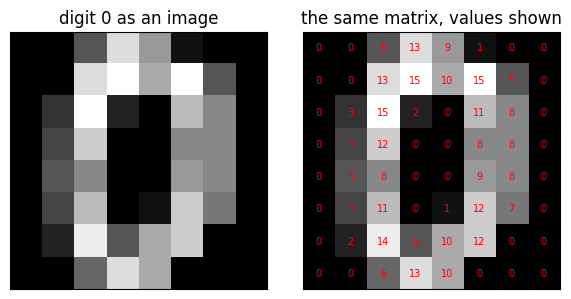

In [2]:
from nnlab.data import load_digits_images

images, y = load_digits_images()                 # images: (m, n_H, n_W) = (1797, 8, 8) float 0-16 | y: (m,)
img8 = images[0]                                 # img8: (n_H, n_W) = (8, 8)
print("images", images.shape, "| dtype", images.dtype, "| label ของภาพแรก =", y[0])
print("ภาพแรกในฐานะ matrix 8×8 (0 = ดำ, 16 = ขาว):")
print(img8.astype(int))

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(img8, cmap="gray"); axes[0].set_title(f"digit {y[0]} as an image")
axes[1].imshow(img8, cmap="gray"); axes[1].set_title("the same matrix, values shown")
for (r, c), v in np.ndenumerate(img8):
    axes[1].text(c, r, int(v), ha="center", va="center", color="red", fontsize=7)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

ภาพจริงใหญ่กว่านั้น: MNIST (ลายมือเลข 0-9) มีขนาด 28×28 และเก็บเป็น `uint8` ค่า 0-255 (มาตรฐานของภาพดิจิทัล 8 bit)
เราโหลดมาแค่ 100 ภาพด้วย `load_mnist(limit=100)` แล้วดูภาพเดียว — สังเกตว่า pixel ส่วนใหญ่เป็น 0 (พื้นดำ) และเส้นตัวเลขเป็นค่าสูง
ภาพนี้จะถูกใช้อีกครั้งในขั้นที่ 7 ตอนเราเอา filter ไปหา edge บนภาพจริง

dtype uint8 | shape (100, 28, 28) | ค่าต่ำสุด-สูงสุด: 0 - 255
label ของภาพแรก = 7 | pixel ที่ไม่ใช่ 0: 99 จาก 784
แถวกลาง (แถว 14) ของภาพ: [  0   0   0   0   0   0   0   0   0   0   0   0   0 180 253 253 148   0
   0   0   0   0   0   0   0   0   0   0]


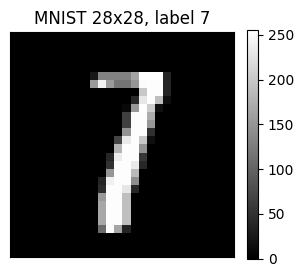

In [3]:
from nnlab.data import load_mnist

mnist_imgs, mnist_y = load_mnist(train=True, limit=100)   # mnist_imgs: (100, 28, 28) uint8 | mnist_y: (100,)
digit = mnist_imgs[0].astype(float)                       # digit: (n_H, n_W) = (28, 28)
print("dtype", mnist_imgs.dtype, "| shape", mnist_imgs.shape, "| ค่าต่ำสุด-สูงสุด:", mnist_imgs.min(), "-", mnist_imgs.max())
print("label ของภาพแรก =", mnist_y[0], "| pixel ที่ไม่ใช่ 0:", int((digit > 0).sum()), "จาก", digit.size)
print("แถวกลาง (แถว 14) ของภาพ:", digit[14].astype(int))

plt.figure(figsize=(3.2, 3.2))
plt.imshow(digit, cmap="gray"); plt.colorbar(fraction=0.046)
plt.title(f"MNIST 28x28, label {mnist_y[0]}"); plt.xticks([]); plt.yticks([]); plt.show()

ภาพสี (สไลด์ p.162) มี 3 channel คือ R, G, B — แต่ละ channel คือ matrix $n_H \times n_W$ หนึ่งอัน ซ้อนกันเป็น **volume** shape `(n_H, n_W, 3)`
cell นี้สร้างภาพ RGB ขึ้นเองด้วย broadcasting จาก lab01: channel R สว่างขึ้นจากซ้ายไปขวา, G สว่างขึ้นจากบนลงล่าง, B คงที่
แล้วแยกดูทีละ channel ด้วย `rgb[:, :, k]` — pixel หนึ่งจุด `rgb[i, j]` คือ vector 3 ตัว (R, G, B)

rgb shape (n_H, n_W, n_C) = (32, 48, 3) | dtype uint8
pixel มุมซ้ายบน  rgb[0, 0]   = [  0   0 128]  (R, G, B)
pixel มุมขวาล่าง rgb[-1, -1] = [255 255 128]


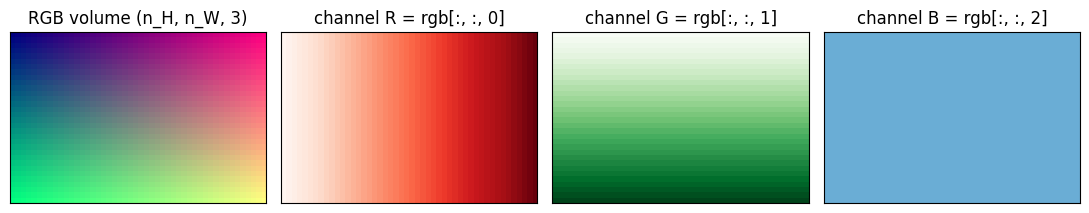

In [4]:
n_H, n_W = 32, 48
rows = np.linspace(0, 255, n_H)[:, None]         # rows: (n_H, 1) ไล่ค่าจากบนลงล่าง
cols = np.linspace(0, 255, n_W)[None, :]         # cols: (1, n_W) ไล่ค่าจากซ้ายไปขวา
R = np.broadcast_to(cols, (n_H, n_W))            # R: (n_H, n_W) สว่างขึ้นทางขวา
G = np.broadcast_to(rows, (n_H, n_W))            # G: (n_H, n_W) สว่างขึ้นด้านล่าง
B = np.full((n_H, n_W), 128.0)                   # B: (n_H, n_W) คงที่
rgb = np.stack([R, G, B], axis=-1).astype(np.uint8)   # rgb: (n_H, n_W, n_C) = (32, 48, 3)
print("rgb shape (n_H, n_W, n_C) =", rgb.shape, "| dtype", rgb.dtype)
print("pixel มุมซ้ายบน  rgb[0, 0]   =", rgb[0, 0], " (R, G, B)")
print("pixel มุมขวาล่าง rgb[-1, -1] =", rgb[-1, -1])

fig, axes = plt.subplots(1, 4, figsize=(11, 2.6))
axes[0].imshow(rgb); axes[0].set_title("RGB volume (n_H, n_W, 3)")
for k, (name, cmap) in enumerate([("R", "Reds"), ("G", "Greens"), ("B", "Blues")]):
    axes[k + 1].imshow(rgb[:, :, k], cmap=cmap, vmin=0, vmax=255)
    axes[k + 1].set_title(f"channel {name} = rgb[:, :, {k}]")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

### ทำไมไม่ flatten แล้วใช้ neural network จาก lab07 (สไลด์ p.163)
วิธีตรงไปตรงมาคือ **flatten** ภาพเป็น vector $x$ ยาว $n_H \cdot n_W \cdot n_C$ แล้วป้อนเข้า fully-connected network ปัญหามี 2 อย่าง
1. **จำนวน feature ระเบิด** — ภาพ 1024×960 RGB ให้ $n_x$ เกือบ 3 ล้าน และ $W^{[1]}$ ของชั้นแรกจะมีขนาด $n^{[1]} \times n_x$
2. **โครงสร้างเพื่อนบ้านหาย** — pixel ที่ติดกันในภาพ (บน-ล่าง) กลายเป็น feature ที่ห่างกัน $n_W$ ตำแหน่งใน vector
   และ fully-connected network ไม่รู้เลยว่า feature ไหน "อยู่ติดกัน": ถ้าเราสลับลำดับ pixel ทุกภาพด้วยลำดับเดียวกัน network จะเรียนได้เท่าเดิมเป๊ะ ทั้งที่ภาพไม่เหลือเค้าเดิม

cell นี้คำนวณตัวเลขของสไลด์ และแสดงภาพเลข 8×8 ที่ถูกสลับ pixel — สำหรับ fully-connected network สองภาพนี้คือ "ข้อมูลเดียวกัน"

flatten: (32, 48, 3) → (4608,) = 32 × 48 × 3
ภาพ 1024×960 RGB → n_x = 1024 × 960 × 3 = 2,949,120 features (สไลด์ p.163)
ถ้าชั้นแรกมี 1,000 unit: W[1] shape (1000, 2,949,120) = 2,949,120,000 ตัว ≈ 24 GB (float64)

ภาพ 32×48: pixel (5,7) → index 247 | เพื่อนขวา (5,8) → 248 (ห่าง 1) | เพื่อนล่าง (6,7) → 295 (ห่าง 48)


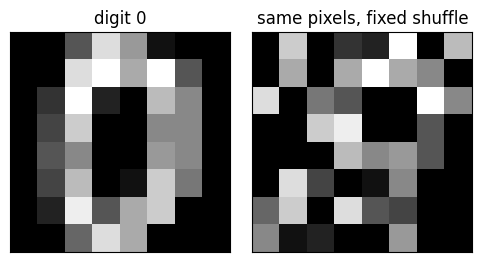

ค่า pixel ชุดเดิม (sorted เท่ากัน): True → fully-connected network แยกสองภาพนี้ไม่ออก


In [5]:
x = rgb.reshape(-1)                              # x: (n_H·n_W·n_C,) = (4608,)
print("flatten:", rgb.shape, "→", x.shape, "=", n_H, "×", n_W, "× 3")
big = 1024 * 960 * 3
print(f"ภาพ 1024×960 RGB → n_x = 1024 × 960 × 3 = {big:,} features (สไลด์ p.163)")
print(f"ถ้าชั้นแรกมี 1,000 unit: W[1] shape (1000, {big:,}) = {big * 1000:,} ตัว ≈ {big * 1000 * 8 / 1e9:.0f} GB (float64)")

i, j = 5, 7
idx = lambda i, j: i * n_W + j                   # index ใน vector ของ pixel (i, j) ของภาพ grayscale (n_H, n_W)
print(f"\nภาพ {n_H}×{n_W}: pixel ({i},{j}) → index {idx(i, j)} | เพื่อนขวา ({i},{j+1}) → {idx(i, j+1)} (ห่าง 1) | เพื่อนล่าง ({i+1},{j}) → {idx(i+1, j)} (ห่าง {n_W})")

perm = rng.permutation(64)                       # ลำดับสลับ pixel (ใช้ลำดับเดียวกันกับทุกภาพ)
shuffled = img8.reshape(-1)[perm].reshape(8, 8)  # shuffled: (8, 8)
fig, axes = plt.subplots(1, 2, figsize=(5, 2.6))
axes[0].imshow(img8, cmap="gray"); axes[0].set_title(f"digit {y[0]}")
axes[1].imshow(shuffled, cmap="gray"); axes[1].set_title("same pixels, fixed shuffle")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()
print("ค่า pixel ชุดเดิม (sorted เท่ากัน):", np.array_equal(np.sort(img8.ravel()), np.sort(shuffled.ravel())), "→ fully-connected network แยกสองภาพนี้ไม่ออก")

## ขั้นที่ 2 · convolution operator (สไลด์ p.165-181)
CNN แก้ทั้งสองปัญหาด้วย **convolution**: แทนที่จะให้ทุก pixel ต่อกับทุก unit เราใช้ **filter** เล็กๆ (เช่น 3×3) ตัวเดียว
เลื่อนไปทั่วภาพ — ที่แต่ละตำแหน่ง output คือ **ผลรวมของการคูณตำแหน่งต่อตำแหน่ง** (pairwise multiplication แล้ว sum — คือ `np.sum(patch * F)` จาก lab01)
$$ (I * F)[i, j] = \sum_{u=0}^{f-1} \sum_{v=0}^{f-1} I[i+u,\ j+v] \cdot F[u, v] $$
filter เล็กจึงมี parameter น้อย (3×3 = 9 ตัว ไม่ว่าภาพจะใหญ่แค่ไหน) และดู pixel **ที่อยู่ติดกัน** เท่านั้น — โครงสร้างเพื่อนบ้านถูกใช้โดยตรง

สไลด์ p.165 ให้ภาพ 6×6 กับ filter 3×3 ตัวหนึ่ง (คอลัมน์ซ้าย +1, กลาง 0, ขวา −1) แล้วเลื่อนทีละ 1 pixel (stride = 1) จากซ้ายไปขวา บนลงล่าง รวม 16 ขั้น
cell นี้เขียน `conv2d` ด้วย loop สองชั้นตามนิยามตรงๆ — loop นอกวิ่งตามตำแหน่ง output, ข้างในตัด patch ขนาด `(f, f)` มาคูณกับ filter

In [6]:
from nnlab.conv import DECK_IMAGE_6x6, VERTICAL_EDGE

I = DECK_IMAGE_6x6                               # I: (n_H, n_W) = (6, 6) ภาพจากสไลด์ p.165
Fv = VERTICAL_EDGE                               # Fv: (f, f) = (3, 3)
print("image I (6×6):\n", I.astype(int))
print("filter F (3×3):\n", Fv.astype(int))

def conv2d(img, filt, stride=1):
    # convolution ตามสไลด์ p.165-166: เลื่อน filter ทีละ stride แล้วเอาผลรวมของการคูณตำแหน่งต่อตำแหน่ง
    n_H, n_W = img.shape
    f = filt.shape[0]
    out_H = (n_H - f) // stride + 1
    out_W = (n_W - f) // stride + 1
    out = np.zeros((out_H, out_W))               # out: (out_H, out_W)
    for i in range(out_H):
        for j in range(out_W):
            patch = img[i * stride : i * stride + f, j * stride : j * stride + f]   # patch: (f, f)
            out[i, j] = np.sum(patch * filt)     # Hadamard product แล้ว sum → ตัวเลขเดียว
    return out

print("\noutput จะมี shape", (I.shape[0] - 3 + 1, I.shape[1] - 3 + 1), "= (6 − 3 + 1) × (6 − 3 + 1)")

image I (6×6):
 [[3 0 1 2 7 4]
 [1 5 8 9 3 1]
 [2 7 2 5 1 3]
 [0 1 3 1 7 8]
 [4 2 1 6 2 8]
 [2 4 5 2 3 9]]
filter F (3×3):
 [[ 1  0 -1]
 [ 1  0 -1]
 [ 1  0 -1]]

output จะมี shape (4, 4) = (6 − 3 + 1) × (6 − 3 + 1)


ก่อนรันทั้งภาพ ทำ 2 ขั้นแรกด้วยมือให้เห็นชัด (สไลด์ p.166-167)
- **step 1**: patch = มุมซ้ายบน `I[0:3, 0:3]` → $3(1) + 0(0) + 1(-1) + 1(1) + 5(0) + 8(-1) + 2(1) + 7(0) + 2(-1) = -5$
- **step 2**: เลื่อนขวา 1 pixel → patch = `I[0:3, 1:4]` → $-4$

สังเกตว่าคอลัมน์กลางของ filter เป็น 0 จึงไม่มีผล และผลลัพธ์คือ (ผลรวมคอลัมน์ซ้ายของ patch) − (ผลรวมคอลัมน์ขวา)

In [7]:
patch1 = I[0:3, 0:3]                             # patch1: (3, 3) มุมซ้ายบน
print("step 1 patch:\n", patch1.astype(int))
print("patch ⊙ F:\n", (patch1 * Fv).astype(int))
terms = " + ".join(f"{int(a)}×{int(b)}" for a, b in zip(patch1.ravel(), Fv.ravel()))
print("sum =", terms)
print("    =", int(np.sum(patch1 * Fv)), "  (สไลด์ p.166: −5)")

patch2 = I[0:3, 1:4]                             # patch2: (3, 3) เลื่อนขวา 1 pixel
print("\nstep 2 patch:\n", patch2.astype(int))
print("sum = คอลัมน์ซ้าย", int(patch2[:, 0].sum()), "− คอลัมน์ขวา", int(patch2[:, 2].sum()), "=", int(np.sum(patch2 * Fv)), "  (สไลด์ p.167: −4)")
assert np.sum(patch1 * Fv) == -5 and np.sum(patch2 * Fv) == -4

step 1 patch:
 [[3 0 1]
 [1 5 8]
 [2 7 2]]
patch ⊙ F:
 [[ 3  0 -1]
 [ 1  0 -8]
 [ 2  0 -2]]
sum = 3×1 + 0×0 + 1×-1 + 1×1 + 5×0 + 8×-1 + 2×1 + 7×0 + 2×-1
    = -5   (สไลด์ p.166: −5)

step 2 patch:
 [[0 1 2]
 [5 8 9]
 [7 2 5]]
sum = คอลัมน์ซ้าย 12 − คอลัมน์ขวา 16 = -4   (สไลด์ p.167: −4)


ทีนี้รัน `conv2d` ทั้งภาพ — ต้องได้ 16 ช่องตรงกับสไลด์ p.181 ทุกช่อง และ shape ต้องเป็น 4×4 (เล็กลงจาก 6×6 — เราจะกลับมาแก้เรื่องนี้ในขั้นที่ 3)

I * F =
 [[ -5  -4   0   8]
 [-10  -2   2   3]
 [  0  -2  -4  -7]
 [ -3  -2  -3 -16]]
ตรงกับสไลด์ p.181 ทั้ง 16 ช่อง ✓ | shape (6, 6) * (3, 3) → (4, 4)


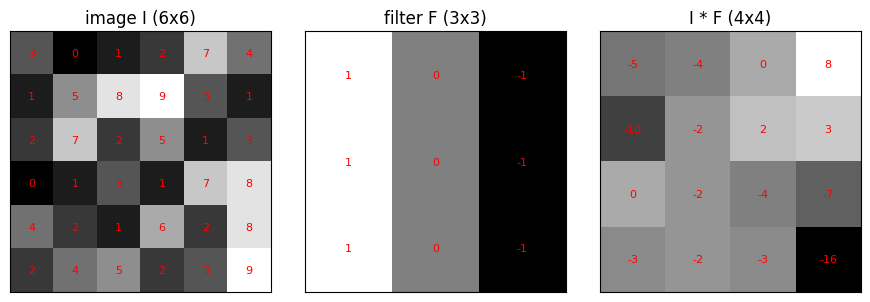

In [8]:
out = conv2d(I, Fv)                              # out: (4, 4)
expected = np.array([[-5, -4, 0, 8], [-10, -2, 2, 3], [0, -2, -4, -7], [-3, -2, -3, -16]])
print("I * F =\n", out.astype(int))
assert np.array_equal(out, expected), "ต้องตรงกับสไลด์ p.181"
print("ตรงกับสไลด์ p.181 ทั้ง 16 ช่อง ✓ | shape", I.shape, "*", Fv.shape, "→", out.shape)

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, M, t in zip(axes, [I, Fv, out], ["image I (6x6)", "filter F (3x3)", "I * F (4x4)"]):
    ax.imshow(M, cmap="gray"); ax.set_title(t); ax.set_xticks([]); ax.set_yticks([])
    for (r, c), v in np.ndenumerate(M):
        ax.text(c, r, int(v), ha="center", va="center", color="red", fontsize=8)
plt.tight_layout(); plt.show()

### filter นี้ "เห็น" อะไร — vertical edge
filter (+1, 0, −1) ตอบสนองแรงเมื่อ**ซ้ายสว่าง ขวามืด** (ผลรวมคอลัมน์ซ้าย − ขวา มีค่ามาก) จึงเรียกว่า **vertical edge detector**
ภาพในสไลด์เป็นตัวเลขสุ่มจึงดูไม่ออก cell นี้สร้างภาพ 6×6 ที่ครึ่งซ้ายเป็น 10 ครึ่งขวาเป็น 0 — มี edge แนวตั้งเส้นเดียวตรงกลาง
คาดว่า output จะเป็น 0 ทุกที่ ยกเว้นคอลัมน์ที่ filter คร่อมรอยต่อพอดี และถ้าใช้ filter แนวนอน (`F.T`) จะได้ 0 ทั้งหมดเพราะไม่มี edge แนวนอน

image:
 [[10 10 10  0  0  0]
 [10 10 10  0  0  0]
 [10 10 10  0  0  0]
 [10 10 10  0  0  0]
 [10 10 10  0  0  0]
 [10 10 10  0  0  0]]
I * F_vertical:
 [[ 0 30 30  0]
 [ 0 30 30  0]
 [ 0 30 30  0]
 [ 0 30 30  0]] 
← ค่าสูง (30 = 3×10 − 3×0) เฉพาะคอลัมน์ที่ filter คร่อมรอยต่อ
I * F_horizontal:
 [[0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]] 
← 0 ทั้งหมด: ไม่มี edge แนวนอน


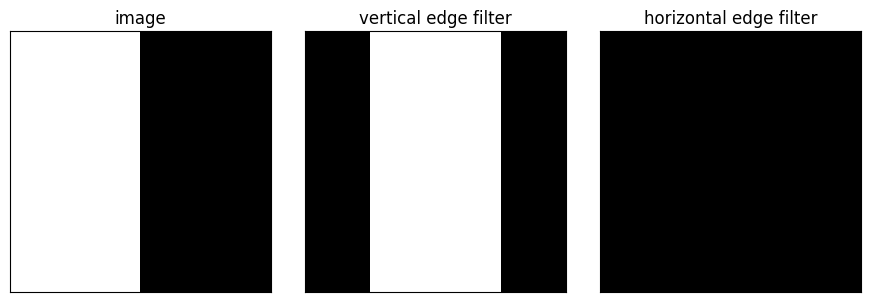

ใน CNN เราไม่ต้องออกแบบ filter เอง — ค่าใน filter คือ weight ที่ gradient descent เรียนได้ (lab12)


In [9]:
from nnlab.conv import HORIZONTAL_EDGE           # = VERTICAL_EDGE.T : แถวบน +1, กลาง 0, ล่าง −1

edge_img = np.zeros((6, 6)); edge_img[:, :3] = 10          # edge_img: (6, 6) ซ้ายสว่าง ขวามืด
edge_v = conv2d(edge_img, VERTICAL_EDGE)                    # (4, 4)
edge_h = conv2d(edge_img, HORIZONTAL_EDGE)                  # (4, 4)
print("image:\n", edge_img.astype(int))
print("I * F_vertical:\n", edge_v.astype(int), "\n← ค่าสูง (30 = 3×10 − 3×0) เฉพาะคอลัมน์ที่ filter คร่อมรอยต่อ")
print("I * F_horizontal:\n", edge_h.astype(int), "\n← 0 ทั้งหมด: ไม่มี edge แนวนอน")

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, M, t in zip(axes, [edge_img, edge_v, edge_h], ["image", "vertical edge filter", "horizontal edge filter"]):
    ax.imshow(M, cmap="gray", vmin=0, vmax=max(M.max(), 1)); ax.set_title(t); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()
print("ใน CNN เราไม่ต้องออกแบบ filter เอง — ค่าใน filter คือ weight ที่ gradient descent เรียนได้ (lab12)")

## ขั้นที่ 3 · image shrink, padding และ stride (สไลด์ p.182-185)
convolution ทำให้ภาพ**เล็กลง** ทุกชั้น: $n \to n - f + 1$ (6 → 4) และยิ่งซ้อนหลายชั้นยิ่งเล็กจนหายไป — **image shrink problem** (p.182)
นอกจากนี้ pixel ริมขอบถูก filter "แตะ" น้อยกว่า pixel ตรงกลาง ข้อมูลที่ขอบจึงถูกใช้น้อย

ทางแก้คือ **padding** (p.183): เติม pixel ค่า 0 รอบภาพ $p$ ชั้นก่อน convolve — ภาพ 6×6 pad 1 ชั้นเป็น 8×8 แล้ว convolve ด้วย 3×3 ได้ 6×6 เท่าเดิม ("same" convolution)
ส่วน **stride** $s$ (p.166) คือระยะที่เลื่อน filter แต่ละครั้ง — $s = 2$ ทำให้ output เล็กลงราวครึ่งหนึ่ง (ใช้ลดขนาดโดยตั้งใจ)
สูตรรวม (p.185):
$$ n_{out} = \left\lfloor \frac{n + 2p - f}{s} \right\rfloor + 1 $$
cell นี้เขียนสูตรเป็นฟังก์ชัน แสดง shrink problem และเขียน `zero_pad` ด้วย `np.pad`

In [10]:
def conv_output_size(n, f, p=0, s=1):
    return (n + 2 * p - f) // s + 1              # ⌊(n + 2p − f)/s⌋ + 1 (สไลด์ p.185)  — // คือ floor

print("ไม่มี padding: 6×6 * 3×3 →", conv_output_size(6, 3), "×", conv_output_size(6, 3))
n = 6
for layer in range(1, 3):
    n = conv_output_size(n, 3)
    print(f"  ผ่าน conv 3×3 ชั้นที่ {layer}: เหลือ {n}×{n}")
print("→ image shrink problem (สไลด์ p.182): ผ่าน 2 ชั้นเหลือ 2×2 — ชั้นที่ 3 วาง filter 3×3 ไม่ได้แล้ว (2 < 3)")

def zero_pad(img, p):
    return np.pad(img, ((p, p), (p, p)))         # เติม 0 ก่อน/หลัง p แถว และ p คอลัมน์ (สไลด์ p.183)

I_pad = zero_pad(I, 1)                           # I_pad: (8, 8)
print("\npadding p=1:", I.shape, "→", I_pad.shape)
print(I_pad.astype(int))
print("padding p=2 →", zero_pad(I, 2).shape)

ไม่มี padding: 6×6 * 3×3 → 4 × 4
  ผ่าน conv 3×3 ชั้นที่ 1: เหลือ 4×4
  ผ่าน conv 3×3 ชั้นที่ 2: เหลือ 2×2
→ image shrink problem (สไลด์ p.182): ผ่าน 2 ชั้นเหลือ 2×2 — ชั้นที่ 3 วาง filter 3×3 ไม่ได้แล้ว (2 < 3)

padding p=1: (6, 6) → (8, 8)
[[0 0 0 0 0 0 0 0]
 [0 3 0 1 2 7 4 0]
 [0 1 5 8 9 3 1 0]
 [0 2 7 2 5 1 3 0]
 [0 0 1 3 1 7 8 0]
 [0 4 2 1 6 2 8 0]
 [0 2 4 5 2 3 9 0]
 [0 0 0 0 0 0 0 0]]
padding p=2 → (10, 10)


สไลด์ p.184 convolve ภาพที่ pad 1 ชั้นด้วย filter เดิม ได้ output 6×6 — cell นี้ทำซ้ำและตรวจทุกช่อง
สังเกต 2 อย่าง: (1) ช่องตรงกลาง 4×4 ของผลลัพธ์คือ output แบบไม่ pad จากขั้นที่ 2 พอดี (2) ขนาดเท่าเดิมได้เมื่อ $p = (f-1)/2$ — นี่คือเหตุผลที่ $f$ มักเป็นเลขคี่ (p.188)

In [11]:
out_pad1 = conv2d(I_pad, Fv)                     # out_pad1: (6, 6)
expected_pad1 = np.array([[-5, -5, -6, -1, 6, 10], [-12, -5, -4, 0, 8, 11], [-13, -10, -2, 2, 3, 11],
                          [-10, 0, -2, -4, -7, 10], [-7, -3, -2, -3, -16, 12], [-6, 0, -2, 1, -9, 5]])
print("pad(I, 1) * F =\n", out_pad1.astype(int))
assert np.array_equal(out_pad1, expected_pad1), "ต้องตรงกับสไลด์ p.184"
print("ตรงกับสไลด์ p.184 ✓ | 6×6 → 6×6 = 'same' convolution")
print("ตรงกลาง out_pad1[1:5, 1:5] == output แบบไม่ pad:", np.array_equal(out_pad1[1:5, 1:5], out))
print("p ที่ทำให้ขนาดเท่าเดิม (s=1): p = (f−1)/2 →", {f: (f - 1) // 2 for f in (3, 5, 7)})

pad(I, 1) * F =
 [[ -5  -5  -6  -1   6  10]
 [-12  -5  -4   0   8  11]
 [-13 -10  -2   2   3  11]
 [-10   0  -2  -4  -7  10]
 [ -7  -3  -2  -3 -16  12]
 [ -6   0  -2   1  -9   5]]
ตรงกับสไลด์ p.184 ✓ | 6×6 → 6×6 = 'same' convolution
ตรงกลาง out_pad1[1:5, 1:5] == output แบบไม่ pad: True
p ที่ทำให้ขนาดเท่าเดิม (s=1): p = (f−1)/2 → {3: 1, 5: 2, 7: 3}


stride 2 เลื่อน filter ทีละ 2 pixel: จาก 6×6 ไม่ pad ได้ $\lfloor (6-3)/2 \rfloor + 1 = 2$ → output 2×2
และเพราะตำแหน่งที่ stride 2 ไปหยุดคือตำแหน่ง (0, 2) ของ stride 1 ผลลัพธ์จึงเท่ากับ `out[::2, ::2]` พอดี
ปิดท้ายด้วยตารางสูตรสำหรับหลายกรณี (รวมตัวเลขที่จะเจอใน lab12: MNIST 28×28, f=5, p=2) และเทียบกับ `nnlab.conv.conv_output_size`

In [12]:
out_s2 = conv2d(I, Fv, stride=2)                 # out_s2: (2, 2)
print("stride 2 (ไม่ pad): 6×6 * 3×3 →", out_s2.shape)
print(out_s2.astype(int))
print("= out[::2, ::2] ของ stride 1:", np.array_equal(out_s2, out[::2, ::2]))

from nnlab.conv import conv_output_size as conv_output_size_nn
cases = [(6, 3, 0, 1), (6, 3, 1, 1), (6, 3, 0, 2), (7, 3, 1, 2), (28, 5, 2, 1), (32, 5, 0, 1), (39, 3, 0, 1), (37, 5, 0, 2)]
print(f"\n{'n':>4}{'f':>4}{'p':>4}{'s':>4}   → n_out")
for n, f, p, s in cases:
    assert conv_output_size(n, f, p, s) == conv_output_size_nn(n, f, p, s)
    print(f"{n:>4}{f:>4}{p:>4}{s:>4}   → {conv_output_size(n, f, p, s)}")

stride 2 (ไม่ pad): 6×6 * 3×3 → (2, 2)
[[-5  0]
 [ 0 -4]]
= out[::2, ::2] ของ stride 1: True

   n   f   p   s   → n_out
   6   3   0   1   → 4
   6   3   1   1   → 6
   6   3   0   2   → 2
   7   3   1   2   → 4
  28   5   2   1   → 28
  32   5   0   1   → 28
  39   3   0   1   → 37
  37   5   0   2   → 17


## ขั้นที่ 4 · convolution ของ volume และ filter หลายตัว (สไลด์ p.186-189)
ภาพสีคือ volume $n_H \times n_W \times n_C$ — filter ต้องมี**ความลึกเท่ากัน** $f \times f \times n_C$ (p.186)
ที่แต่ละตำแหน่ง เราคูณ patch ขนาด $f \times f \times n_C$ กับ filter ตำแหน่งต่อตำแหน่ง แล้วรวม**ทุก channel**เป็นตัวเลขเดียว → filter หนึ่งตัวให้ output **1 channel**
อยากได้หลาย feature (edge แนวตั้ง, แนวนอน, ...) ก็ใช้หลาย filter: $n_F$ ตัว → output มี $n_F$ channel (p.187-188)
$$ (n_H \times n_W \times n_C) * (f \times f \times n_C) \times n_F \;\to\; \left(\tfrac{n_H + 2p - f}{s} + 1\right) \times \left(\tfrac{n_W + 2p - f}{s} + 1\right) \times n_F $$
ตัวอย่างสไลด์ p.189: $6 \times 6 \times 3$ กับ filter $3 \times 3 \times 3$ จำนวน 2 ตัว, $s = 1$, $p = 1$ → $6 \times 6 \times 2$

cell นี้เก็บ filter ทั้งหมดใน array เดียว shape `(f, f, n_C, n_F)` (ตามสไลด์ p.191) และเพิ่ม loop ชั้นนอกสุดวนตาม filter
filter 0 คือ vertical edge ซ้อนกัน 3 channel, filter 1 คือ horizontal edge — เราตรวจว่า channel 0 ของ output = ผลรวมของ conv ทีละ channel

In [13]:
vol = rng.integers(0, 10, size=(6, 6, 3)).astype(float)   # vol: (n_H, n_W, n_C) = (6, 6, 3)
filters = np.zeros((3, 3, 3, 2))                          # filters: (f, f, n_C, n_F) = (3, 3, 3, 2)
filters[:, :, :, 0] = VERTICAL_EDGE[:, :, None]           # filter 0: vertical edge ทุก channel (broadcast (3,3,1) → (3,3,3))
filters[:, :, :, 1] = HORIZONTAL_EDGE[:, :, None]         # filter 1: horizontal edge
bias = np.array([0.0, 0.0])                               # bias: (n_F,) หนึ่งค่าต่อ filter (สไลด์ p.191: 1×1×1×n_F)

def conv2d_volume(vol, filters, bias, stride=1, pad=0):
    vol = np.pad(vol, ((pad, pad), (pad, pad), (0, 0)))   # pad เฉพาะ H, W — ไม่ pad channel
    f, _, n_C, n_F = filters.shape
    assert vol.shape[2] == n_C, "ความลึกของ filter ต้องเท่า channel ของภาพ"
    out_H = (vol.shape[0] - f) // stride + 1
    out_W = (vol.shape[1] - f) // stride + 1
    out = np.zeros((out_H, out_W, n_F))                   # out: (out_H, out_W, n_F)
    for k in range(n_F):                                  # ทีละ filter → ทีละ channel ของ output
        for i in range(out_H):
            for j in range(out_W):
                patch = vol[i * stride : i * stride + f, j * stride : j * stride + f, :]   # patch: (f, f, n_C)
                out[i, j, k] = np.sum(patch * filters[:, :, :, k]) + bias[k]              # รวมทุก channel เป็นเลขเดียว
    return out

out_vol = conv2d_volume(vol, filters, bias, stride=1, pad=1)   # out_vol: (6, 6, 2)
print("(6, 6, 3) * (3, 3, 3) × 2 filters, s=1, p=1 →", out_vol.shape, "  (สไลด์ p.189: 6×6×2)")
print("output channel 0 (vertical edge):\n", out_vol[:, :, 0].astype(int))

check = sum(conv2d(zero_pad(vol[:, :, c], 1), VERTICAL_EDGE) for c in range(3))   # conv ทีละ channel แล้วบวก
assert np.allclose(out_vol[:, :, 0], check)
print("= ผลรวมของ conv2d ทีละ channel ✓ (นี่คือความหมายของ 'รวมทุก channel')")

(6, 6, 3) * (3, 3, 3) × 2 filters, s=1, p=1 → (6, 6, 2)   (สไลด์ p.189: 6×6×2)
output channel 0 (vertical edge):
 [[-26  -7   1  -5  -9  32]
 [-35   5  -8  -9   8  43]
 [-33  11 -11 -12  17  46]
 [-39   7   6 -14  13  52]
 [-41 -14  16  -2   0  55]
 [-28 -11  15   4  -3  34]]
= ผลรวมของ conv2d ทีละ channel ✓ (นี่คือความหมายของ 'รวมทุก channel')


### นับ parameter ของชั้น conv
ชั้น conv มี weight = ค่าใน filter ทุกตัว $f \cdot f \cdot n_C \cdot n_F$ บวก bias $n_F$ ตัว — **ไม่ขึ้นกับขนาดภาพเลย** เพราะ filter เดียวกันถูกใช้ซ้ำทุกตำแหน่ง (weight sharing)
เทียบกับ fully-connected ที่ต่อ input ทุกตัวกับ output ทุกตัว

In [14]:
def conv_params(f, n_C, n_F):
    return f * f * n_C * n_F + n_F               # weights + bias

n_in, n_out = 6 * 6 * 3, 6 * 6 * 2
print("ชั้นนี้ (f=3, n_C=3, n_F=2): parameters =", conv_params(3, 3, 2), "= 3·3·3·2 weights + 2 bias")
print(f"fully-connected จาก {n_in} → {n_out}: parameters = {n_in * n_out + n_out:,}")
print("CONV1 ของ LeNet-5 (f=5, n_C=1, n_F=6):", conv_params(5, 1, 6), "| CONV2 (f=5, n_C=6, n_F=16):", conv_params(5, 6, 16))
print("AlexNet ชั้นแรก (f=11, n_C=3, n_F=96):", f"{conv_params(11, 3, 96):,}")
print("→ ภาพ 28×28 หรือ 1024×960 ก็ใช้ parameter เท่ากัน — ต่างจาก fully-connected ที่โตตาม n_x")

ชั้นนี้ (f=3, n_C=3, n_F=2): parameters = 56 = 3·3·3·2 weights + 2 bias
fully-connected จาก 108 → 72: parameters = 7,848
CONV1 ของ LeNet-5 (f=5, n_C=1, n_F=6): 156 | CONV2 (f=5, n_C=6, n_F=16): 2416
AlexNet ชั้นแรก (f=11, n_C=3, n_F=96): 34,944
→ ภาพ 28×28 หรือ 1024×960 ก็ใช้ parameter เท่ากัน — ต่างจาก fully-connected ที่โตตาม n_x


## ขั้นที่ 5 · pooling (สไลด์ p.192-198)
**pooling** ลดขนาด $n_H, n_W$ โดยสรุปแต่ละบริเวณเล็กๆ ให้เหลือเลขเดียว — **max pooling** เอาค่าสูงสุด (p.193) ใช้บ่อยที่สุด
ค่าที่ตั้งได้คือ $f$ กับ $s$ เท่านั้น (ปกติ $f = s = 2$ → ขนาดลดครึ่ง) และ**ไม่มี parameter ให้เรียน** (p.198)
สไลด์ p.193-196 ทำทีละขั้นบนภาพ 4×4: หน้าต่าง 2×2 ทั้ง 4 ช่อง → [[9, 2], [6, 3]] cell นี้ทำซ้ำและพิมพ์ทุกขั้น

In [15]:
from nnlab.conv import POOL_EXAMPLE_4x4

P = POOL_EXAMPLE_4x4                             # P: (4, 4) จากสไลด์ p.193
print("input 4×4:\n", P.astype(int))
f, s = 2, 2
out_H, out_W = (P.shape[0] - f) // s + 1, (P.shape[1] - f) // s + 1
pooled = np.zeros((out_H, out_W))                # pooled: (2, 2)
step = 1
for i in range(out_H):
    for j in range(out_W):
        window = P[i * s : i * s + f, j * s : j * s + f]   # window: (2, 2)
        pooled[i, j] = window.max()
        print(f"step {step}: window {window.astype(int).tolist()} → max = {int(pooled[i, j])}")
        step += 1
print("\nmax pool f=2, s=2 →\n", pooled.astype(int))
assert pooled.tolist() == [[9, 2], [6, 3]], "ต้องตรงกับสไลด์ p.196"
print("ตรงกับสไลด์ p.196 ✓ | สูตรขนาด: ⌊(4 − 2)/2⌋ + 1 =", conv_output_size(4, 2, 0, 2))

input 4×4:
 [[1 3 2 1]
 [2 9 1 1]
 [1 3 2 3]
 [5 6 1 2]]
step 1: window [[1, 3], [2, 9]] → max = 9
step 2: window [[2, 1], [1, 1]] → max = 2
step 3: window [[1, 3], [5, 6]] → max = 6
step 4: window [[2, 3], [1, 2]] → max = 3

max pool f=2, s=2 →
 [[9 2]
 [6 3]]
ตรงกับสไลด์ p.196 ✓ | สูตรขนาด: ⌊(4 − 2)/2⌋ + 1 = 2


เมื่อ input เป็น volume หลาย channel pooling ทำ**แยกทีละ channel** จำนวน channel จึงไม่เปลี่ยน (p.197): $5 \times 5 \times 2$ กับ $f = 3, s = 1$ → $3 \times 3 \times 2$
cell นี้ใช้ channel หน้าของสไลด์ p.197 เป็น channel 0 (แถวบนของ output ต้องเป็น 9, 9, 8 ตามสไลด์) และสุ่ม channel 1 ขึ้นเอง
`.max(axis=(0, 1))` หา max ของหน้าต่างในแนว H, W พร้อมกันแต่ **แยกตาม channel** (ทบทวน axis จาก lab01)

In [16]:
ch0 = np.array([[2, 9, 1, 1, 1], [3, 2, 3, 8, 3], [5, 1, 5, 6, 1], [2, 1, 3, 2, 1], [3, 2, 9, 1, 1]], dtype=float)  # (5, 5) จากสไลด์ p.197
ch1 = rng.integers(0, 10, size=(5, 5)).astype(float)                                                                 # (5, 5) สุ่ม
vol2 = np.stack([ch0, ch1], axis=-1)             # vol2: (n_H, n_W, n_C) = (5, 5, 2)

def max_pool2d(vol, f=2, s=2):
    out_H, out_W = (vol.shape[0] - f) // s + 1, (vol.shape[1] - f) // s + 1
    out = np.zeros((out_H, out_W, vol.shape[2]))          # out: (out_H, out_W, n_C) — channel เท่าเดิม
    for i in range(out_H):
        for j in range(out_W):
            out[i, j, :] = vol[i * s : i * s + f, j * s : j * s + f, :].max(axis=(0, 1))   # max แยกทีละ channel
    return out

pooled2 = max_pool2d(vol2, f=3, s=1)             # pooled2: (3, 3, 2)
print("5×5×2 → max pool f=3, s=1 →", pooled2.shape, "  (สไลด์ p.197: 3×3×2)")
print("channel 0 input:\n", ch0.astype(int), "\nchannel 0 output:\n", pooled2[:, :, 0].astype(int))
assert pooled2[0, :, 0].tolist() == [9, 9, 8], "แถวบนต้องเป็น 9, 9, 8 ตามสไลด์ p.197"
print("channel 1 output:\n", pooled2[:, :, 1].astype(int))
print("แถวบนของ channel 0 = 9, 9, 8 ตรงกับสไลด์ ✓ | parameter ที่ต้องเรียน: 0")

5×5×2 → max pool f=3, s=1 → (3, 3, 2)   (สไลด์ p.197: 3×3×2)
channel 0 input:
 [[2 9 1 1 1]
 [3 2 3 8 3]
 [5 1 5 6 1]
 [2 1 3 2 1]
 [3 2 9 1 1]] 
channel 0 output:
 [[9 9 8]
 [5 8 8]
 [9 9 9]]
channel 1 output:
 [[7 8 8]
 [8 8 8]
 [9 9 9]]
แถวบนของ channel 0 = 9, 9, 8 ตรงกับสไลด์ ✓ | parameter ที่ต้องเรียน: 0


**average pooling** ใช้ค่าเฉลี่ยแทน max — LeNet-5 ดั้งเดิม (p.202) ใช้แบบนี้ แต่ปัจจุบันใช้น้อย (p.198 "Rarely used") เพราะ max เก็บ "feature ที่เด่นที่สุด" ในบริเวณนั้นได้ดีกว่า

In [17]:
avg = np.zeros((2, 2))                           # avg: (2, 2)
for i in range(2):
    for j in range(2):
        avg[i, j] = P[2 * i : 2 * i + 2, 2 * j : 2 * j + 2].mean()
print("average pool f=2, s=2 →\n", avg)
print("ช่องซ้ายบน = (1 + 3 + 2 + 9)/4 =", (1 + 3 + 2 + 9) / 4, "| max pool ช่องเดียวกัน = 9")
from nnlab.conv import avg_pool2d
assert np.allclose(avg, avg_pool2d(P))

average pool f=2, s=2 →
 [[3.75 1.25]
 [3.75 2.  ]]
ช่องซ้ายบน = (1 + 3 + 2 + 9)/4 = 3.75 | max pool ช่องเดียวกัน = 9


## ขั้นที่ 6 · numpy | torch เทียบบรรทัดต่อบรรทัด
PyTorch มีทุกอย่างที่เราเพิ่งเขียนใน `torch.nn.functional` (import เป็น `F`): `F.conv2d` และ `F.max_pool2d` — แต่ layout ต่างกัน
- สไลด์/numpy: ภาพ `(n_H, n_W)` หรือ `(n_H, n_W, n_C)`, filter `(f, f, n_C, n_F)`
- torch: ภาพ `(N, C, H, W)` — มิติ batch `N` นำหน้าเสมอ (แม้มีภาพเดียวก็ต้อง `N = 1`) และ channel อยู่**หน้า** H, W; filter `(n_F, C, f, f)`

สอง cell ถัดไปทำงานเดียวกัน: cell แรกคือ numpy ของเรา (ผลจากขั้นก่อน) cell ที่สองคือ torch แล้ว `np.allclose` เทียบ
เริ่มจากภาพ grayscale ต้อง "เพิ่ม" มิติ N และ C ด้วย `[None, None]` → `(1, 1, 6, 6)`

In [18]:
# numpy (layout สไลด์): ภาพ (6, 6), filter (3, 3) — ผลจากขั้นที่ 2-5
out_np      = conv2d(I, Fv)                              # (4, 4)   p=0, s=1
out_np_pad1 = conv2d(zero_pad(I, 1), Fv)                 # (6, 6)   p=1
out_np_s2   = conv2d(I, Fv, stride=2)                    # (2, 2)   s=2
pool_np     = max_pool2d(P[:, :, None], f=2, s=2)[:, :, 0]   # (2, 2)  เพิ่ม channel ชั่วคราวเพื่อใช้ฟังก์ชัน volume
print("numpy: conv", out_np.shape, "| pad1", out_np_pad1.shape, "| stride2", out_np_s2.shape, "| pool", pool_np.shape)
print(out_np.astype(int))

numpy: conv (4, 4) | pad1 (6, 6) | stride2 (2, 2) | pool (2, 2)
[[ -5  -4   0   8]
 [-10  -2   2   3]
 [  0  -2  -4  -7]
 [ -3  -2  -3 -16]]


**torch** — งานเดียวกันบรรทัดต่อบรรทัด: `torch.tensor(I)[None, None]` เพิ่มมิติ N และ C ให้ภาพเดียว, `F.conv2d(x, w, stride, padding)` และ `F.max_pool2d(x, kernel_size, stride)`
ผลลัพธ์มี 4 มิติเสมอ จึงต้องดึงภาพออกด้วย `[0, 0]` (batch 0, channel 0) ก่อนเทียบกับ numpy

In [19]:
# torch: เพิ่มมิติ N (batch) และ C (channel) → (N, C, H, W)
I_t  = torch.tensor(I)[None, None]                       # I_t : (1, 1, 6, 6)
Fv_t = torch.tensor(Fv)[None, None]                      # Fv_t: (n_F, C, f, f) = (1, 1, 3, 3)
out_t      = F.conv2d(I_t, Fv_t, stride=1, padding=0)    # (1, 1, 4, 4)
out_t_pad1 = F.conv2d(I_t, Fv_t, padding=1)              # (1, 1, 6, 6)
out_t_s2   = F.conv2d(I_t, Fv_t, stride=2)               # (1, 1, 2, 2)
pool_t     = F.max_pool2d(torch.tensor(P)[None, None], kernel_size=2, stride=2)   # (1, 1, 2, 2)
print("torch: conv", tuple(out_t.shape), "| pad1", tuple(out_t_pad1.shape), "| stride2", tuple(out_t_s2.shape), "| pool", tuple(pool_t.shape))
print(out_t[0, 0].numpy().astype(int))

assert np.allclose(out_t[0, 0].numpy(), out_np)
assert np.allclose(out_t_pad1[0, 0].numpy(), out_np_pad1)
assert np.allclose(out_t_s2[0, 0].numpy(), out_np_s2)
assert np.allclose(pool_t[0, 0].numpy(), pool_np)
print("F.conv2d (p=0, p=1, s=2) และ F.max_pool2d ตรงกับ numpy ทุกช่อง ✓  (ดึงภาพออกด้วย [0, 0] = batch 0, channel 0)")

torch: conv (1, 1, 4, 4) | pad1 (1, 1, 6, 6) | stride2 (1, 1, 2, 2) | pool (1, 1, 2, 2)
[[ -5  -4   0   8]
 [-10  -2   2   3]
 [  0  -2  -4  -7]
 [ -3  -2  -3 -16]]
F.conv2d (p=0, p=1, s=2) และ F.max_pool2d ตรงกับ numpy ทุกช่อง ✓  (ดึงภาพออกด้วย [0, 0] = batch 0, channel 0)


### "convolution" ใน deep learning คือ cross-correlation
ในคณิตศาสตร์/การประมวลผลสัญญาณ convolution แท้ต้อง**กลับ filter** (หมุน 180°) ก่อนเลื่อน — `scipy.signal.convolve2d` ทำแบบนั้น
แต่สไลด์, `F.conv2d` และ CNN ทุกตัว **ไม่กลับ** filter (เรียกให้ถูกคือ cross-correlation) เพราะ filter เป็นสิ่งที่เรียนได้ กลับหรือไม่กลับก็เรียนได้ค่าเดียวกัน
cell นี้แสดงว่า scipy ให้ผลต่างจากเรา แต่เท่ากับ `conv2d` ของเราเมื่อกลับ filter ก่อน — จำไว้เวลาเทียบกับ library อื่น

In [20]:
from scipy.signal import convolve2d

flipped = Fv[::-1, ::-1]                         # กลับทั้งแนวตั้งและแนวนอน (หมุน 180°)
print("F กลับ 180°:\n", flipped.astype(int))
true_conv = convolve2d(I, Fv, mode="valid")      # convolution แท้ (scipy กลับ filter ให้เอง) (4, 4)
print("scipy convolve2d:\n", true_conv.astype(int))
print("= conv2d ของเรา กับ filter ที่กลับแล้ว:", np.array_equal(true_conv, conv2d(I, flipped)))
print("≠ F.conv2d / สไลด์            :", not np.array_equal(true_conv, out_np), "→ deep learning 'convolution' = cross-correlation")

F กลับ 180°:


 [[-1  0  1]
 [-1  0  1]
 [-1  0  1]]
scipy convolve2d:
 [[ 5  4  0 -8]
 [10  2 -2 -3]
 [ 0  2  4  7]
 [ 3  2  3 16]]
= conv2d ของเรา กับ filter ที่กลับแล้ว: True
≠ F.conv2d / สไลด์            : True → deep learning 'convolution' = cross-correlation


สำหรับ volume ต้อง **permute** แกน: `(H, W, C)` → `(C, H, W)` แล้วเพิ่ม N; filter `(f, f, C, n_F)` → `(n_F, C, f, f)`
`permute(2, 0, 1)` หมายถึง "แกนใหม่ 0 = แกนเดิม 2, แกนใหม่ 1 = แกนเดิม 0, ..." — ตรวจ shape หลัง permute ทุกครั้ง
ผลจาก torch มี layout `(1, n_F, H, W)` เราจึง permute กลับเป็น `(H, W, n_F)` ก่อนเทียบกับ `conv2d_volume` ของเรา

In [21]:
x_t = torch.tensor(vol).permute(2, 0, 1)[None]                  # (6, 6, 3) → (3, 6, 6) → (1, 3, 6, 6)
w_t = torch.tensor(filters).permute(3, 2, 0, 1)                 # (3, 3, 3, 2) → (n_F, C, f, f) = (2, 3, 3, 3)
out_vol_t = F.conv2d(x_t, w_t, torch.tensor(bias), padding=1)   # (1, 2, 6, 6)
back = out_vol_t[0].permute(1, 2, 0).numpy()                    # (2, 6, 6) → (6, 6, 2) กลับเป็น layout สไลด์
print("torch:", tuple(x_t.shape), "*", tuple(w_t.shape), "→", tuple(out_vol_t.shape), "| permute กลับ →", back.shape)
assert np.allclose(back, out_vol)
print("ตรงกับ conv2d_volume ของเรา ✓")

pool_vol_t = F.max_pool2d(torch.tensor(vol2).permute(2, 0, 1)[None], kernel_size=3, stride=1)   # (1, 2, 3, 3)
assert np.allclose(pool_vol_t[0].permute(1, 2, 0).numpy(), pooled2)
print("F.max_pool2d บน 5×5×2 (f=3, s=1) ตรงกับ max_pool2d ของเรา ✓")

torch: (1, 3, 6, 6) * (2, 3, 3, 3) → (1, 2, 6, 6) | permute กลับ → (6, 6, 2)
ตรงกับ conv2d_volume ของเรา ✓
F.max_pool2d บน 5×5×2 (f=3, s=1) ตรงกับ max_pool2d ของเรา ✓


## ขั้นที่ 7 · เดิน shape ผ่าน CNN ทั้งตัว (สไลด์ p.190-191, 199-200)
สไลด์ p.191 สรุป notation: ชั้น conv $l$ มี $f^{[l]}, p^{[l]}, s^{[l]}, n_F^{[l]}$; filter แต่ละตัว $f^{[l]} \times f^{[l]} \times n_F^{[l-1]}$; activation $a^{[l]}$ มี shape $n_H^{[l]} \times n_W^{[l]} \times n_F^{[l]}$
ทักษะสำคัญคือ "เดิน shape" ผ่านทุกชั้นได้โดยไม่ต้องรันโมเดล — ใช้สูตรขั้นที่ 3 กับ 5 ซ้ำๆ

ตัวอย่างสไลด์ p.190: $39 \times 39 \times 3 \to 37 \times 37 \times 10 \to 17 \times 17 \times 20 \to 7 \times 7 \times 40 \to$ flatten 1960
สังเกตแนวโน้ม: $n_H, n_W$ **ลดลง** ส่วน $n_C$ **เพิ่มขึ้น** เมื่อลึกลง
cell นี้เดินด้วยมือก่อน แล้วใช้ `nnlab.conv.describe_cnn` พิมพ์ตาราง activation shape / size / #parameters

In [22]:
from nnlab.conv import describe_cnn, format_cnn_table

n, n_C = 39, 3
print("input 39×39×3")
for f, s, n_F in [(3, 1, 10), (5, 2, 20), (5, 2, 40)]:
    n = conv_output_size(n, f, 0, s)
    print(f"  conv f={f}, s={s}, p=0, n_F={n_F:2d} → {n}×{n}×{n_F}   (parameters {f * f * n_C * n_F + n_F:,})")
    n_C = n_F
print("  flatten →", n * n * n_C, "× 1")

simple = describe_cnn((39, 39, 3), [{"type": "conv", "f": 3, "s": 1, "p": 0, "n_f": 10},
                                    {"type": "conv", "f": 5, "s": 2, "p": 0, "n_f": 20},
                                    {"type": "conv", "f": 5, "s": 2, "p": 0, "n_f": 40},
                                    {"type": "flatten"}])
print("\n" + format_cnn_table(simple))
assert [r["shape"] for r in simple] == [(39, 39, 3), (37, 37, 10), (17, 17, 20), (7, 7, 40), (1960,)]

input 39×39×3
  conv f=3, s=1, p=0, n_F=10 → 37×37×10   (parameters 280)
  conv f=5, s=2, p=0, n_F=20 → 17×17×20   (parameters 5,020)
  conv f=5, s=2, p=0, n_F=40 → 7×7×40   (parameters 20,040)
  flatten → 1960 × 1

Layer                           Activation shape        Size   #Params
Input                           39×39×3                4,563         0
CONV1 (f=3, s=1, p=0, n_F=10)   37×37×10              13,690       280
CONV2 (f=5, s=2, p=0, n_F=20)   17×17×20               5,780     5,020
CONV3 (f=5, s=2, p=0, n_F=40)   7×7×40                 1,960    20,040
Flatten                         1960                   1,960         0
รวม parameters                                                  25,340


### LeNet-style network ของสไลด์ p.199-200
CONV → POOL → CONV → POOL → FC → FC → Softmax บน input 32×32×3: CONV1 ($f=5, n_F=6$) → 28×28×6 → POOL1 → 14×14×6 → CONV2 ($f=5, n_F=16$) → 10×10×16 → POOL2 → 5×5×16 → flatten 400 → FC 120 → FC 84 → 10

> **errata สไลด์ p.199-200:** diagram เขียน CONV2 เป็น 10×10×**10** แต่ต้องเป็น 10×10×**16** (POOL2 = 5×5×16 และ flatten = 5·5·16 = 400 จะถูกต้องก็ต่อเมื่อ CONV2 มี 16 channel)
> และตาราง p.200 ใช้ CONV1/POOL1 เป็น 8 channel (6,272 / 1,568) ขณะที่ diagram และ LeNet-5 (p.202) ใช้ 6 → activation size ที่ถูกคือ 28·28·6 = 4,704 และ 14·14·6 = 1,176 เราใช้ 6/16 ตาม LeNet-5 ตลอด lab12

ตารางจาก `describe_cnn` ด้านล่างคือค่าที่ถูก — สังเกตว่า parameter เกือบทั้งหมดอยู่ที่ FC ชั้นแรก (400×120) ไม่ใช่ที่ conv

In [23]:
lenet_layers = [{"type": "conv", "f": 5, "s": 1, "p": 0, "n_f": 6}, {"type": "pool", "f": 2, "s": 2},
                {"type": "conv", "f": 5, "s": 1, "p": 0, "n_f": 16}, {"type": "pool", "f": 2, "s": 2},
                {"type": "fc", "units": 120}, {"type": "fc", "units": 84}, {"type": "fc", "units": 10}]
lenet = describe_cnn((32, 32, 3), lenet_layers)
print(format_cnn_table(lenet))
shapes = [r["shape"] for r in lenet]
assert shapes[:5] == [(32, 32, 3), (28, 28, 6), (14, 14, 6), (10, 10, 16), (5, 5, 16)] and (400,) in shapes
print("\nCONV2 = 10×10×16 (สไลด์เขียน ×10) | CONV1 size = 28·28·6 =", 28 * 28 * 6, "(ตาราง p.200 เขียน 6,272 จาก 8 channel)")
print("W[3] ของ FC3 = 120 × 400 ตามสไลด์ p.199 → parameters 120·400 + 120 =", 120 * 400 + 120)

Layer                           Activation shape        Size   #Params
Input                           32×32×3                3,072         0
CONV1 (f=5, s=1, p=0, n_F=6)    28×28×6                4,704       456
POOL1 (f=2, s=2)                14×14×6                1,176         0
CONV2 (f=5, s=1, p=0, n_F=16)   10×10×16               1,600     2,416
POOL2 (f=2, s=2)                5×5×16                   400         0
Flatten                         400                      400         0
FC1                             120                      120    48,120
FC2                             84                        84    10,164
FC3                             10                        10       850
รวม parameters                                                  62,006

CONV2 = 10×10×16 (สไลด์เขียน ×10) | CONV1 size = 28·28·6 = 4704 (ตาราง p.200 เขียน 6,272 จาก 8 channel)
W[3] ของ FC3 = 120 × 400 ตามสไลด์ p.199 → parameters 120·400 + 120 = 48120


### filter บนภาพจริง
ปิดท้ายด้วยการเอา vertical/horizontal edge filter ไปใช้กับภาพ MNIST จากขั้นที่ 1 — output 26×26 (28 − 3 + 1)
vertical edge filter ให้ค่าบวกที่ขอบซ้ายของเส้น (ซ้ายมืด→ขวาสว่าง คือค่าลบ, สว่าง→มืด คือค่าบวก) และ horizontal edge filter จับขอบบน/ล่างของเส้น
นี่คือ "feature" ที่ชั้น conv แรกของ CNN มักเรียนได้เอง (จะเห็นจริงใน lab12)

digit (28, 28) → conv 3×3 → (26, 26) | ช่วงค่า vertical: -759 ถึง 761


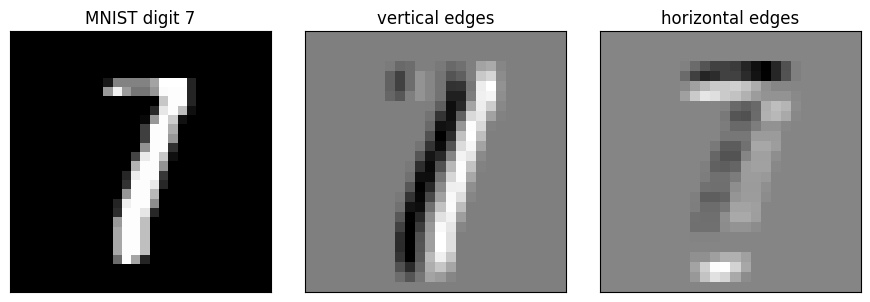

In [24]:
edge_v_digit = conv2d(digit, VERTICAL_EDGE)      # (26, 26)
edge_h_digit = conv2d(digit, HORIZONTAL_EDGE)    # (26, 26)
print("digit", digit.shape, "→ conv 3×3 →", edge_v_digit.shape, "| ช่วงค่า vertical:", int(edge_v_digit.min()), "ถึง", int(edge_v_digit.max()))

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, M, t in zip(axes, [digit, edge_v_digit, edge_h_digit], [f"MNIST digit {mnist_y[0]}", "vertical edges", "horizontal edges"]):
    ax.imshow(M, cmap="gray"); ax.set_title(t); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## ขั้นที่ 8 · เวอร์ชัน production ใน `nnlab`
โค้ดที่เราเพิ่งเขียนใน cell ด้านบนคือ "โค้ดเพื่อความเข้าใจ" — แยกทุกขั้นให้เห็น
ในการใช้งานจริง โค้ดเดียวกันถูกจัดเป็นฟังก์ชัน/คลาสใน `src/nnlab/conv.py` พร้อม docstring, type hints และ test
cell ถัดไปเรียกเวอร์ชัน production มาเทียบกับที่เราเขียนเอง (conv2d_single, zero_pad, conv_output_size, conv2d_volume, max_pool2d) — ตัวเลขต้องตรงกัน
เปิดไฟล์ `src/nnlab/conv.py` ควบคู่กันเพื่อดูว่าโค้ด "ทดลอง" กลายเป็นโค้ด "ใช้งานจริง" ได้อย่างไร

In [25]:
from nnlab.conv import conv2d_single, conv2d_volume as conv2d_volume_nn, max_pool2d as max_pool2d_nn, zero_pad as zero_pad_nn

assert np.array_equal(conv2d_single(I, Fv), out)                       # ขั้นที่ 2: 4×4 ของสไลด์ p.181
assert np.array_equal(conv2d_single(I, Fv, pad=1), out_pad1)           # ขั้นที่ 3: p=1 ของสไลด์ p.184
assert np.array_equal(conv2d_single(I, Fv, stride=2), out_s2)          # ขั้นที่ 3: s=2
assert np.array_equal(zero_pad_nn(I, 1), I_pad)
assert all(conv_output_size(*c) == conv_output_size_nn(*c) for c in cases)
assert np.allclose(conv2d_volume_nn(vol, filters, bias, stride=1, pad=1), out_vol)   # ขั้นที่ 4: 6×6×2
assert max_pool2d_nn(P, f=2, s=2).tolist() == [[9, 2], [6, 3]]         # ขั้นที่ 5
assert np.allclose(max_pool2d_nn(vol2, f=3, s=1), pooled2)
print("conv2d_single / zero_pad / conv_output_size / conv2d_volume / max_pool2d ของ nnlab ให้ผลตรงกับที่เราเขียนเองทุกตัว ✓")
print("conv2d_single(digit, VERTICAL_EDGE) shape:", conv2d_single(digit, VERTICAL_EDGE).shape, "— ฟังก์ชันเดียวใช้ได้ทั้งภาพสไลด์และภาพจริง")

conv2d_single / zero_pad / conv_output_size / conv2d_volume / max_pool2d ของ nnlab ให้ผลตรงกับที่เราเขียนเองทุกตัว ✓
conv2d_single(digit, VERTICAL_EDGE) shape: (26, 26) — ฟังก์ชันเดียวใช้ได้ทั้งภาพสไลด์และภาพจริง


## ★ Key Takeaways
- ภาพคือ matrix `(n_H, n_W)` (grayscale) หรือ volume `(n_H, n_W, n_C)` (RGB); flatten แล้วต่อ fully-connected ทำให้ feature ระเบิด (1024×960×3 ≈ 2.9 ล้าน) และทิ้งโครงสร้างเพื่อนบ้าน
- convolution = เลื่อน filter ไปทุกตำแหน่ง แล้วเอา `np.sum(patch * F)` — filter 3×3 มีแค่ 9 weight ใช้ซ้ำทุกตำแหน่ง (weight sharing) และ deep learning ไม่กลับ filter (cross-correlation)
- ขนาด output = ⌊(n + 2p − f)/s⌋ + 1: convolution ทำให้ภาพหด (6→4) · padding p = (f−1)/2 รักษาขนาด · stride s ลดขนาดโดยตั้งใจ
- volume: filter ต้องลึกเท่า n_C และรวมทุก channel เป็นเลขเดียว; n_F filter → output n_F channel; parameter = f·f·n_C·n_F + n_F ไม่ขึ้นกับขนาดภาพ
- max pooling (f=2, s=2) ลดขนาดครึ่งหนึ่ง ทำแยกทีละ channel และไม่มี parameter; ยิ่งลึก n_H, n_W ลด ส่วน n_C เพิ่ม (39×39×3 → 7×7×40)
- torch ใช้ layout `(N, C, H, W)` — `[None, None]` เพิ่มมิติให้ภาพเดียว, `permute` สลับแกน; `F.conv2d`/`F.max_pool2d` ให้ผลตรงกับ loop ของเราทุกช่อง

## แบบฝึกหัด (ทำเอง)
ส่วนนี้ต้อง**เขียนโค้ดเอง** — แต่ละข้อมี 3 cell: โจทย์ (อ่านให้จบก่อน) → cell โครง (มี `raise NotImplementedError` ให้แทนที่ด้วยโค้ดของคุณ) → cell ตรวจคำตอบ
cell ตรวจคำตอบรันได้ทันที: ถ้ายังไม่ได้ทำจะขึ้น ⏳ ถ้าผิดจะขึ้น ✗ พร้อมคำใบ้ ถ้าถูกจะขึ้น ✓ PASS
ทำได้ไม่จำกัดรอบ แก้แล้วรัน cell โครงและ cell ตรวจซ้ำ ใช้ผลจาก cell ก่อนหน้าใน lab นี้ได้ทุกตัว

In [26]:
from nnlab.exercise import check, check_close, check_shape, summary, reset
reset()   # ล้างผลการตรวจเก่าใน kernel นี้

### แบบฝึกหัด 11.1 · horizontal edge filter บนภาพจากสไลด์
**เป้าหมาย:** ใช้ `conv2d` ที่เขียนในขั้นที่ 2 convolve ภาพ `I` (6×6 จากสไลด์ p.165) กับ `HORIZONTAL_EDGE` แล้วยืนยันว่าเท่ากับการ transpose ภาพ, convolve ด้วย `VERTICAL_EDGE`, แล้ว transpose กลับ

**ขั้นตอน**
1. กำหนด `out_h` = ผลของ `conv2d(I, HORIZONTAL_EDGE)` (stride 1 ไม่ pad) → shape `(4, 4)`
2. กำหนด `out_h_via_T` = convolve `I.T` ด้วย `VERTICAL_EDGE` แล้ว `.T` กลับ — ต้องได้ค่าเท่ากับ `out_h` ทุกช่อง เพราะ `HORIZONTAL_EDGE = VERTICAL_EDGE.T`
3. พิมพ์ทั้งสอง แล้วดูว่าค่ามากสุด (17) อยู่ช่องไหน — คือบริเวณที่แถวบนของ patch สว่างกว่าแถวล่างมากที่สุด

<details><summary>คำใบ้ (คลิกเพื่อเปิด)</summary>

- `HORIZONTAL_EDGE` ถูก import ไว้แล้วในขั้นที่ 2 (แถวบน +1, กลาง 0, ล่าง −1)
- transpose สลับแถวกับคอลัมน์ทั้งภาพและ filter: `(I.T * F.T).T == I * F` เมื่อ `F.T` คือ filter แนวนอน
</details>

In [27]:
# --- แบบฝึกหัด 11.1: เขียนโค้ดของคุณใน cell นี้ (แทนที่ raise NotImplementedError) ---
out_h = ...                    # TODO: conv2d(I, HORIZONTAL_EDGE) → (4, 4)
out_h_via_T = ...              # TODO: transpose I → convolve ด้วย VERTICAL_EDGE → transpose กลับ → (4, 4)
print("I * F_horizontal =", out_h)
print("ผ่าน transpose    =", out_h_via_T)

I * F_horizontal = Ellipsis
ผ่าน transpose    = Ellipsis


In [28]:
# --- ตรวจคำตอบ 11.1 (รันได้ทันที ไม่ต้องแก้) ---
from nnlab.conv import conv2d_single as _conv_nn
ref_h = _conv_nn(I, HORIZONTAL_EDGE)                                                             # เวอร์ชัน production (คนละโค้ด)
ref_torch = F.conv2d(torch.tensor(I)[None, None], torch.tensor(HORIZONTAL_EDGE)[None, None])[0, 0].numpy()   # torch (คนละ library)
check_shape("11.1 out_h shape (4, 4)", lambda: out_h, (4, 4), hint="6 − 3 + 1 = 4 ทั้งสองแกน")
check_close("11.1 out_h ตรงกับ nnlab.conv.conv2d_single", lambda: out_h, ref_h, hint="conv2d(I, HORIZONTAL_EDGE) — ใช้ filter แนวนอน ไม่ใช่ Fv")
check_close("11.1 out_h ตรงกับ F.conv2d ของ torch", lambda: out_h, ref_torch)
check_close("11.1 out_h_via_T ให้ค่าเดียวกัน", lambda: out_h_via_T, ref_h, hint="conv2d(I.T, VERTICAL_EDGE).T — อย่าลืม .T ครั้งที่สองที่ผลลัพธ์")

⏳ 11.1 out_h shape (4, 4): ยังไม่ได้ทำ
⏳ 11.1 out_h ตรงกับ nnlab.conv.conv2d_single: ยังไม่ได้ทำ
⏳ 11.1 out_h ตรงกับ F.conv2d ของ torch: ยังไม่ได้ทำ
⏳ 11.1 out_h_via_T ให้ค่าเดียวกัน: ยังไม่ได้ทำ


False

### แบบฝึกหัด 11.2 · สูตรขนาด output และชั้นแรกของ AlexNet
**เป้าหมาย:** เขียนสูตร ⌊(n + 2p − f)/s⌋ + 1 เป็นฟังก์ชันของตัวเอง แล้วใช้เดิน shape ชั้นแรกของ AlexNet (สไลด์ p.203): ภาพ 227×227×3 → conv f=11, s=4, p=0, 96 filter → max pool f=3, s=2

**ขั้นตอน**
1. เขียน `output_size(n, f, p=0, s=1)` คืนจำนวนเต็ม (ใช้ `//` สำหรับ floor) — ห้ามเรียก `conv_output_size` ของ lab หรือ nnlab
2. กำหนด `alex_conv` = ขนาดด้านหนึ่งหลัง conv ชั้นแรก (n=227, f=11, s=4, p=0) โดยเรียก `output_size` ของคุณ
3. กำหนด `alex_pool` = ขนาดหลัง max pool f=3, s=2 (p=0) ที่ต่อจาก `alex_conv` — pooling ใช้สูตรเดียวกัน
4. กำหนด `alex_params` = จำนวน parameter ของ conv ชั้นแรก (f·f·n_C·n_F + n_F ตามขั้นที่ 4) เมื่อ n_C=3, n_F=96

<details><summary>คำใบ้ (คลิกเพื่อเปิด)</summary>

- `//` คือหารปัดลง (floor) — สูตรบอกให้ปัดลงเมื่อหารไม่ลงตัว เช่น (227 − 11)/4 = 54 พอดี แต่ (55 − 3)/2 = 26 ก็พอดี
- ค่าที่ควรได้: 55×55×96 หลัง conv และ 27×27×96 หลัง pool — ตรงกับตารางในสไลด์ p.203
</details>

In [29]:
# --- แบบฝึกหัด 11.2: เขียนโค้ดของคุณใน cell นี้ (แทนที่ raise NotImplementedError) ---
def output_size(n, f, p=0, s=1):
    """ขนาด output ด้านหนึ่ง = ⌊(n + 2p − f)/s⌋ + 1 (สไลด์ p.185) — คืน int"""
    raise NotImplementedError("ยังไม่ได้ทำ")

alex_conv = ...          # TODO: ใช้ output_size กับ n=227, f=11, s=4 (คาดว่า 55)
alex_pool = ...          # TODO: max pool f=3, s=2 ต่อจาก alex_conv (คาดว่า 27)
alex_params = ...        # TODO: weights + bias ของ conv ชั้นแรก (n_C=3, n_F=96)
# print("227 →", alex_conv, "→", alex_pool, "| parameters", alex_params)

In [30]:
# --- ตรวจคำตอบ 11.2 (รันได้ทันที ไม่ต้องแก้) ---
from nnlab.conv import conv_output_size as _cos
grid = [(6, 3, 0, 1), (6, 3, 1, 1), (6, 3, 0, 2), (28, 5, 2, 1), (39, 3, 0, 1), (37, 5, 0, 2), (17, 5, 0, 2), (227, 11, 0, 4)]
check("11.2 output_size ตรงกับ nnlab.conv.conv_output_size ทั้ง 8 กรณี", lambda: all(output_size(n, f, p, s) == _cos(n, f, p, s) for n, f, p, s in grid), hint="(n + 2*p - f) // s + 1 — ใช้ // ไม่ใช่ /")
check("11.2 output_size คืน int (ไม่ใช่ float)", lambda: isinstance(output_size(7, 3, 1, 2), int), hint="ถ้าใช้ / จะได้ float — ใช้ // หรือครอบด้วย int(...)")
check_close("11.2 AlexNet conv1: 227 → 55", lambda: alex_conv, 55, hint="(227 + 0 − 11) // 4 + 1")
check_close("11.2 AlexNet pool1: 55 → 27", lambda: alex_pool, 27, hint="output_size(alex_conv, 3, 0, 2)")
check_close("11.2 parameters ของ conv1 = 34,944", lambda: alex_params, 34944, hint="11·11·3·96 weights บวก bias 96 ตัว (สูตร conv_params ในขั้นที่ 4)")

⏳ 11.2 output_size ตรงกับ nnlab.conv.conv_output_size ทั้ง 8 กรณี: ยังไม่ได้ทำ
⏳ 11.2 output_size คืน int (ไม่ใช่ float): ยังไม่ได้ทำ
⏳ 11.2 AlexNet conv1: 227 → 55: ยังไม่ได้ทำ
⏳ 11.2 AlexNet pool1: 55 → 27: ยังไม่ได้ทำ
⏳ 11.2 parameters ของ conv1 = 34,944: ยังไม่ได้ทำ


False

### แบบฝึกหัด 11.3 · average pooling ทีละ channel
**เป้าหมาย:** เขียน `avg_pool2d_vol(vol, f=2, s=2)` สำหรับ volume `(n_H, n_W, n_C)` ที่ทำเหมือน `max_pool2d` ของขั้นที่ 5 แต่ใช้ค่าเฉลี่ยของหน้าต่างแทนค่ามากสุด (LeNet-5 ดั้งเดิม สไลด์ p.202)

**ขั้นตอน**
1. คำนวณ `out_H, out_W` ด้วยสูตรขนาด output (p=0) แล้วสร้าง `out = np.zeros((out_H, out_W, n_C))` — channel เท่าเดิม
2. วน `i, j` ทุกตำแหน่ง output ตัดหน้าต่าง `vol[i*s : i*s+f, j*s : j*s+f, :]` แล้วใช้ `.mean(axis=(0, 1))` — เฉลี่ยในแนว H, W แต่แยกทีละ channel
3. ทดสอบกับ `P[:, :, None]` (ภาพ 4×4 จากสไลด์ p.193 เพิ่ม channel) → ช่องซ้ายบนต้องเป็น (1+3+2+9)/4 = 3.75
4. ทดสอบกับ `vol2` (5×5×2 จากขั้นที่ 5) ด้วย f=3, s=1 → shape `(3, 3, 2)`

<details><summary>คำใบ้ (คลิกเพื่อเปิด)</summary>

- คัดลอกโครงของ `max_pool2d` ในขั้นที่ 5 มาแล้วเปลี่ยน `.max(axis=(0, 1))` เป็น `.mean(axis=(0, 1))`
- `vol.shape[2]` คือจำนวน channel — output ต้องมี channel เท่านี้เสมอ (pooling ไม่รวม channel)
</details>

In [31]:
# --- แบบฝึกหัด 11.3: เขียนโค้ดของคุณใน cell นี้ (แทนที่ raise NotImplementedError) ---
def avg_pool2d_vol(vol, f=2, s=2):
    """average pooling ทีละ channel: vol (n_H, n_W, n_C) → (out_H, out_W, n_C)"""
    raise NotImplementedError("ยังไม่ได้ทำ")

# print(avg_pool2d_vol(P[:, :, None])[:, :, 0])

In [32]:
# --- ตรวจคำตอบ 11.3 (รันได้ทันที ไม่ต้องแก้) ---
from nnlab.conv import avg_pool2d as _avg_nn
ref_vol2 = F.avg_pool2d(torch.tensor(vol2).permute(2, 0, 1)[None], kernel_size=3, stride=1)[0].permute(1, 2, 0).numpy()   # torch (แปลง layout ไปกลับ)
check_shape("11.3 P 4×4 (1 channel) → (2, 2, 1)", lambda: avg_pool2d_vol(P[:, :, None]), (2, 2, 1), hint="out_H = (n_H − f)//s + 1 และมิติ channel ต้องคงอยู่")
check_close("11.3 ค่าบน P = [[3.75, 1.25], [3.75, 2.0]]", lambda: avg_pool2d_vol(P[:, :, None])[:, :, 0], [[3.75, 1.25], [3.75, 2.0]], hint="ใช้ .mean ไม่ใช่ .max — ช่องซ้ายบน (1+3+2+9)/4")
check_close("11.3 ตรงกับ nnlab.conv.avg_pool2d บน P", lambda: avg_pool2d_vol(P[:, :, None])[:, :, 0], _avg_nn(P))
check_shape("11.3 vol2 5×5×2, f=3, s=1 → (3, 3, 2)", lambda: avg_pool2d_vol(vol2, f=3, s=1), (3, 3, 2), hint="อย่า hardcode f=2, s=2 ในสูตรขนาด — ใช้ค่า f, s ที่รับเข้ามา")
check_close("11.3 vol2 ตรงกับ F.avg_pool2d ของ torch", lambda: avg_pool2d_vol(vol2, f=3, s=1), ref_vol2, hint="mean(axis=(0, 1)) เฉลี่ยเฉพาะ H, W — ห้ามเฉลี่ยข้าม channel")

⏳ 11.3 P 4×4 (1 channel) → (2, 2, 1): ยังไม่ได้ทำ
⏳ 11.3 ค่าบน P = [[3.75, 1.25], [3.75, 2.0]]: ยังไม่ได้ทำ
⏳ 11.3 ตรงกับ nnlab.conv.avg_pool2d บน P: ยังไม่ได้ทำ
⏳ 11.3 vol2 5×5×2, f=3, s=1 → (3, 3, 2): ยังไม่ได้ทำ
⏳ 11.3 vol2 ตรงกับ F.avg_pool2d ของ torch: ยังไม่ได้ทำ


False

### แบบฝึกหัด 11.4 · "same" convolution: เลือก padding ให้ output เท่า input
**เป้าหมาย:** เขียน `conv2d_same(img, filt)` ที่คำนวณ p = (f − 1)/2 เอง แล้ว zero-pad ก่อน convolve (stride 1) เพื่อให้ output มีขนาดเท่าภาพเดิมเสมอ — แล้วใช้กับภาพ MNIST `digit` 28×28

**ขั้นตอน**
1. อ่าน f จาก `filt.shape[0]` (ต้องเป็นเลขคี่) แล้วคำนวณ `p = (f - 1) // 2`
2. pad ภาพด้วย `zero_pad(img, p)` จากขั้นที่ 3 แล้วเรียก `conv2d` จากขั้นที่ 2 ด้วย stride 1 — คืนผลลัพธ์
3. ทดสอบกับ `I` และ `Fv`: ต้องได้ 6×6 ตรงกับสไลด์ p.184 (ตัวแปร `expected_pad1` จากขั้นที่ 3)
4. ทดสอบกับ filter 5×5 (`filt5` ที่สร้างให้) และกับ `digit` 28×28 → output ต้องเท่า input ทุกกรณี

<details><summary>คำใบ้ (คลิกเพื่อเปิด)</summary>

- `zero_pad(img, p)` และ `conv2d(img, filt, stride=1)` เขียนไว้แล้วในขั้นที่ 2-3 — ฟังก์ชันนี้แค่ต่อสองอย่างเข้าด้วยกันโดยคำนวณ p เอง
- ตรวจง่ายๆ: n + 2p − f + 1 = n ก็ต่อเมื่อ p = (f − 1)/2 — จึงต้องใช้ f คี่ (สไลด์ p.188)
</details>

In [33]:
# --- แบบฝึกหัด 11.4: เขียนโค้ดของคุณใน cell นี้ (แทนที่ raise NotImplementedError) ---
def conv2d_same(img, filt):
    """convolution แบบ 'same': img (n_H, n_W), filt (f, f) โดย f คี่ → output (n_H, n_W)"""
    raise NotImplementedError("ยังไม่ได้ทำ")

filt5 = rng.normal(size=(5, 5))          # filt5: (5, 5) filter สุ่มสำหรับทดสอบ p=2
# print(conv2d_same(I, Fv).astype(int))

In [34]:
# --- ตรวจคำตอบ 11.4 (รันได้ทันที ไม่ต้องแก้) ---
from nnlab.conv import conv2d_single as _conv_nn
ref_digit = F.conv2d(torch.tensor(digit)[None, None], torch.tensor(VERTICAL_EDGE)[None, None], padding=1)[0, 0].numpy()   # torch same padding
check_shape("11.4 I 6×6 * 3×3 → (6, 6)", lambda: conv2d_same(I, Fv), (6, 6), hint="p = (f − 1)//2 = 1 สำหรับ f=3")
check_close("11.4 ค่าตรงกับสไลด์ p.184 (expected_pad1)", lambda: conv2d_same(I, Fv), expected_pad1, hint="zero_pad ก่อน แล้วค่อย conv2d(..., stride=1)")
check_shape("11.4 I 6×6 * 5×5 → (6, 6)", lambda: conv2d_same(I, filt5), (6, 6), hint="p ต้องคำนวณจาก f ไม่ใช่ hardcode 1")
check_close("11.4 filter 5×5 ตรงกับ nnlab.conv.conv2d_single(pad=2)", lambda: conv2d_same(I, filt5), _conv_nn(I, filt5, pad=2))
check_shape("11.4 digit 28×28 → (28, 28)", lambda: conv2d_same(digit, VERTICAL_EDGE), (28, 28))
check_close("11.4 digit ตรงกับ F.conv2d(padding=1) ของ torch", lambda: conv2d_same(digit, VERTICAL_EDGE), ref_digit)

⏳ 11.4 I 6×6 * 3×3 → (6, 6): ยังไม่ได้ทำ
⏳ 11.4 ค่าตรงกับสไลด์ p.184 (expected_pad1): ยังไม่ได้ทำ
⏳ 11.4 I 6×6 * 5×5 → (6, 6): ยังไม่ได้ทำ
⏳ 11.4 filter 5×5 ตรงกับ nnlab.conv.conv2d_single(pad=2): ยังไม่ได้ทำ
⏳ 11.4 digit 28×28 → (28, 28): ยังไม่ได้ทำ
⏳ 11.4 digit ตรงกับ F.conv2d(padding=1) ของ torch: ยังไม่ได้ทำ


False

### สรุปผลแบบฝึกหัด
รัน cell นี้หลังทำครบทุกข้อ (รัน cell ตรวจของทุกข้อก่อน)

In [35]:
summary()

สรุป: PASS 0/20 · FAIL 0 · ยังไม่ได้ทำ 20


{'pass': 0, 'fail': 0, 'todo': 20, 'error': 0}